#preprocessing

In [1]:
#database installation
!pip -q install opendatasets
from pathlib import Path
import opendatasets as od

RAW = Path("/content/data"); RAW.mkdir(parents=True, exist_ok=True)
od.download("https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated",
            data_dir=str(RAW/"plant_village_updated"))
print("Ready at:", RAW/"plant_village_updated")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: amalaseiri
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated


100%|██████████| 1.00G/1.00G [00:05<00:00, 214MB/s]



Ready at: /content/data/plant_village_updated


In [2]:
#  Total number of images
from pathlib import Path
import os, shutil, re, numpy as np

# # Root dataset directory
ROOT = Path("/content/data/plant_village_updated")
assert ROOT.exists(), f"المجلد غير موجود: {ROOT}"
# Detects when the dataset resides inside a single nested folder
subdirs = [d for d in ROOT.iterdir() if d.is_dir()]
if len(subdirs) == 1 and not (ROOT/"train").exists():
    ROOT = subdirs[0]
print("Using dataset root:", ROOT)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image(p: Path):
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean_text(s: str):
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

#  Unified output directory
UNIFIED = ROOT.parent / (ROOT.name + "_unified")
if UNIFIED.exists():
    shutil.rmtree(UNIFIED)
for sp in ["train","val","test"]:
    (UNIFIED/sp).mkdir(parents=True, exist_ok=True)

# Possible split aliases
SPLIT_ALIASES = {
    "train": ["train","Train","TRAIN","training","Training"],
    "val":   ["val","Val","valid","Valid","validation","Validation"],
    "test":  ["test","Test","TEST","testing","Testing"],
}

rng = np.random.default_rng(42)

def copy_images(src_files, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img in src_files:
        tgt = dst_dir / img.name
        # إن وجد اسم مكرر، ضف لاحقة
        if tgt.exists():
            stem, suf = tgt.stem, tgt.suffix
            k = 1
            while (dst_dir / f"{stem}_{k}{suf}").exists():
                k += 1
            tgt = dst_dir / f"{stem}_{k}{suf}"
        shutil.copy2(img, tgt)

# Process each crop category
crops = [d for d in ROOT.iterdir() if d.is_dir()]
total_copied = 0
for crop in crops:
    crop_name = clean_text(crop.name)

    # Detect if crop contains predefined train/val/test folders
    found_split = False
    split_dirs = {}
    for split_key, aliases in SPLIT_ALIASES.items():
        for name in aliases:
            cand = crop / name
            if cand.exists():
                split_dirs[split_key] = cand
                found_split = True
                break

    if found_split:
        # Use existing split structure
        for split_key, split_dir in split_dirs.items():
            for disease_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
                disease_name = clean_text(disease_dir.name)
                class_name = f"{crop_name} - {disease_name}"
                files = [p for p in disease_dir.rglob("*") if is_image(p)]
                copy_images(files, UNIFIED / split_key / class_name)
                total_copied += len(files)
    else:
        #  No predefined split → apply manual 70/15/15 split
        disease_dirs = [d for d in crop.iterdir() if d.is_dir()]
        for disease_dir in disease_dirs:
            disease_name = clean_text(disease_dir.name)
            class_name = f"{crop_name} - {disease_name}"
            files = [p for p in disease_dir.rglob("*") if is_image(p)]
            if not files:
                continue
            rng.shuffle(files)
            n = len(files)
            n_train = int(n * 0.70)
            n_val   = int(n * 0.15)
            n_test  = n - n_train - n_val
            splits = {
                "train": files[:n_train],
                "val"  : files[n_train:n_train+n_val],
                "test" : files[n_train+n_val:]
            }
            for split_key, group in splits.items():
                copy_images(group, UNIFIED / split_key / class_name)
            total_copied += n

print("Unified dataset built at:", UNIFIED)
print("Total copied images:", total_copied)


Using dataset root: /content/data/plant_village_updated/plant-village-dataset-updated
Unified dataset built at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total copied images: 67118


In [3]:
# Total number of images in train, val, and test
# Listing all class names for each crop

from collections import defaultdict
import pandas as pd

# 1- Automatically determine the dataset root (either DATA_DIR or UNIFIED)
ROOT = None
for cand in [globals().get("DATA_DIR"), globals().get("UNIFIED")]:
    if cand is None:
        continue
    cand = Path(cand)
    if (cand/"train").exists():
        ROOT = cand
        break
assert ROOT is not None, "حددي ROOT: إما DATA_DIR (من resplit) أو UNIFIED (من التوحيد) ويحتوي مجلد train/."

#2- Helper functions
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def count_images_dir(d: Path) -> int:
    return sum(1 for p in d.rglob("*") if is_image(p))

#3- Determine available splits based on folder structure
splits = ["train","val"] + (["test"] if (ROOT/"test").exists() else [])

# 4- Calculations for each class in the format "Crop - Disease" + grouping by crop
by_crop = defaultdict(list)
rows = []

train_class_dirs = sorted([d for d in (ROOT/"train").iterdir() if d.is_dir()], key=lambda x: x.name)

for d in train_class_dirs:
    name = d.name
    if " - " in name:
        crop_name, disease = name.split(" - ", 1)
    else:
        parts = name.split()
        crop_name, disease = parts[0], " ".join(parts[1:]) if len(parts)>1 else "(Unknown)"

    counts = {s: count_images_dir(ROOT/s/name) for s in splits}
    counts["total"] = sum(counts.values())

    by_crop[crop_name].append((disease, name, counts))
    rows.append({
        "crop": crop_name,
        "class_name": name,
        "disease": disease,
        **{s: counts[s] for s in splits},
        "total": counts["total"]
    })

#5- Print detailed class breakdown per crop
print("\n Classes by crop (with image counts):")
for crop_name in sorted(by_crop.keys()):
    items = sorted(by_crop[crop_name], key=lambda x: x[0])
    crop_tot = {s: sum(it[2][s] for it in items) for s in splits}
    crop_tot["total"] = sum(crop_tot.values())
    header = " | ".join([f"{s}={crop_tot[s]}" for s in splits] + [f"total={crop_tot['total']}"])
    print(f"\n{crop_name} ({len(items)} classes) [{header}]")
    for i, (dz, class_name, cnts) in enumerate(items, 1):
        line = " | ".join([f"{s}:{cnts[s]}" for s in splits] + [f"Σ:{cnts['total']}"])
        print(f"  {i:2d}. {dz} -> {line}")

# 6- save as result CSV
df = pd.DataFrame(rows)
csv_path = ROOT / "class_counts_by_crop.csv"
df.to_csv(csv_path, index=False)
print("\n Saved counts table to:", csv_path)

# 7- Compute overall image totals per split and the global total
totals = {s: count_images_dir(ROOT/s) for s in splits}
grand_total = sum(totals.values())
print("\n Totals (images per split):")
for s in splits:
    print(f"  {s:<5} = {totals[s]}")
print(f"  total = {grand_total}")



 Classes by crop (with image counts):

Apple (4 classes) [train=7771 | val=1747 | test=196 | total=9714]
   1. Apple Scab -> train:2016 | val:453 | test:51 | Σ:2520
   2. Black Rot -> train:1987 | val:447 | test:50 | Σ:2484
   3. Cedar Apple Rust -> train:1760 | val:396 | test:44 | Σ:2200
   4. Healthy -> train:2008 | val:451 | test:51 | Σ:2510

Bell Pepper (2 classes) [train=3901 | val=877 | test=98 | total=4876]
   1. Bacterial Spot -> train:1913 | val:430 | test:48 | Σ:2391
   2. Healthy -> train:1988 | val:447 | test:50 | Σ:2485

Cherry (2 classes) [train=3509 | val=788 | test=89 | total=4386]
   1. Healthy -> train:1826 | val:410 | test:46 | Σ:2282
   2. Powdery Mildew -> train:1683 | val:378 | test:43 | Σ:2104

Corn (Maize) (4 classes) [train=7316 | val=1645 | test=188 | total=9149]
   1. Cercospora Leaf Spot -> train:1642 | val:369 | test:45 | Σ:2056
   2. Common Rust -> train:1907 | val:429 | test:48 | Σ:2384
   3. Healthy -> train:1859 | val:418 | test:47 | Σ:2324
   4. North

In [4]:
#  Unifing / Renaming

from pathlib import Path
import shutil, re
from collections import Counter
import pandas as pd

# --------General settings (paths and image extensions)--------
SRC = Path("/content/data/plant_village_updated/plant-village-dataset-updated")  # Source
DST = SRC.parent / (SRC.name + "_unified")                                      # Output folder
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
SPLITS = {"train","val","test"}  # إن وُجدت

DST.mkdir(parents=True, exist_ok=True)

def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean(s: str) -> str:
    s = s.replace("_", " ")
    s = re.sub(r"[()]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def split_plant_disease(name: str):
    """Extract plant and disease labels from folder names."""
    n = clean(name)

    # Patterns 'Plant - Disease'
    if " - " in n:
        plant, disease = n.split(" - ", 1)
        return clean(plant), clean(disease)


    plants = [
        "Apple","Bell Pepper","Cherry","Corn (Maize)","Corn Maize","Grape",
        "Peach","Potato","Strawberry","Tomato"
    ]
    for plant in plants:
        if n.lower().startswith(plant.lower()):
            disease = clean(n[len(plant):])
            plant = "Corn (Maize)" if plant.lower() in {"corn maize","corn (maize)"} else plant
            return plant, disease

    return None, None

def iter_leaf_folders(base: Path):

    """Locate image folders and infer their labels."""

    for plant_dir in base.iterdir():
        if not plant_dir.is_dir():
            continue

        # Case: "Plant - Disease"
        p_plant, p_dis = split_plant_disease(plant_dir.name)
        if p_plant and p_dis and any(is_image(x) for x in plant_dir.rglob("*")):
            yield (p_plant, p_dis, plant_dir)
            continue


        plant_name = clean(plant_dir.name)


        subdirs = [d for d in plant_dir.iterdir() if d.is_dir()]
        if not subdirs: # images directly inside plant folder

            if any(is_image(x) for x in plant_dir.iterdir()):
                yield (plant_name, "", plant_dir)
            continue


        split_dirs = [d for d in subdirs if d.name.lower() in SPLITS]
        if split_dirs: # train/val/test structure
            for sp in split_dirs:
                for disease_dir in [d for d in sp.iterdir() if d.is_dir()]:
                    if any(is_image(x) for x in disease_dir.iterdir()):
                        yield (plant_name, clean(disease_dir.name), disease_dir)
            continue

       # plant/disease structure
        for disease_dir in subdirs:
            if any(is_image(x) for x in disease_dir.iterdir()):
                # ممكن يكون disease_dir اسمه "Plant - Disease"
                pp, dd = split_plant_disease(disease_dir.name)
                if pp and dd:
                    yield (pp, dd, disease_dir)
                else:
                    yield (plant_name, clean(disease_dir.name), disease_dir)

def unique_copy(src: Path, dst_dir: Path):

    """Copy image while preventing filename conflicts."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    name = src.name
    target = dst_dir / name
    if not target.exists():
        shutil.copy2(src, target)
        return target

    stem, suf = src.stem, src.suffix
    k = 1
    while True:
        cand = dst_dir / f"{stem}_{k}{suf}"
        if not cand.exists():
            shutil.copy2(src, cand)
            return cand
        k += 1

# -------- Execution --------
counts = Counter()
mappings = []   # (plant, disease, src_dir, dst_class, num_imgs)
unmatched = []

for plant, disease, src_dir in iter_leaf_folders(SRC):

    plant = clean(plant) if plant else ""
    disease = clean(disease) if disease else "Healthy"
    dst_class = f"{plant} {disease}".strip()
    dst_class = re.sub(r"\s+", " ", dst_class)

    n_before = counts[dst_class]
    for p in src_dir.iterdir():
        if is_image(p):
            unique_copy(p, DST / dst_class)
            counts[dst_class] += 1

    n_new = counts[dst_class] - n_before
    mappings.append((plant, disease, str(src_dir), dst_class, n_new))


    if not plant or dst_class.lower() in {"", "healthy"}:
        unmatched.append((plant or "?", disease or "?", str(src_dir)))

# -------- Reporting --------
print(f"Unified dataset created at: {DST}")
print(f"Total classes: {len(counts)}")
print(f" Total images: {sum(counts.values())}\n")

print("Classes & counts:")
for cls in sorted(counts):
    print(f"- {cls}: {counts[cls]}")


df = pd.DataFrame(mappings, columns=["plant","disease","src_dir","dst_class","copied_images"])
csv_path = DST / "unify_report.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\n Saved mapping report: {csv_path}")

if unmatched:
    print("\n Unmatched/weakly parsed entries (check and rerun if needed):")
    for plant, disease, src in unmatched[:30]:
        print(f"- plant='{plant}' disease='{disease}' from: {src}")
    if len(unmatched) > 30:
        print(f"... and {len(unmatched)-30} more")

Unified dataset created at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total classes: 29
 Total images: 67111

Classes & counts:
- Apple Apple Scab: 2520
- Apple Black Rot: 2484
- Apple Cedar Apple Rust: 2200
- Apple Healthy: 2510
- Bell Pepper Bacterial Spot: 2391
- Bell Pepper Healthy: 2485
- Cherry Healthy: 2282
- Cherry Powdery Mildew: 2104
- Corn Maize Cercospora Leaf Spot: 2052
- Corn Maize Common Rust: 2384
- Corn Maize Healthy: 2324
- Corn Maize Northern Leaf Blight: 2385
- Grape Black Rot: 2360
- Grape Esca Black Measles: 2400
- Grape Healthy: 2115
- Grape Leaf Blight: 2152
- Peach Bacterial Spot: 2297
- Peach Healthy: 2160
- Potato Early Blight: 2424
- Potato Healthy: 2280
- Potato Late Blight: 2424
- Strawberry Healthy: 2280
- Strawberry Leaf Scorch: 2218
- Tomato Bacterial Spot: 2127
- Tomato Early Blight: 2400
- Tomato Healthy: 2407
- Tomato Late Blight: 2314
- Tomato Septoria Leaf Spot: 2181
- Tomato Yellow Leaf Curl Virus: 2451

 Saved mapp

In [5]:
# Remove Duplicates
# ===== Remove Duplicates (phash) – fixed & safe =====
!pip -q install imagehash
from pathlib import Path
from PIL import Image, ImageFile
import imagehash, pandas as pd, shutil, collections, os

# 0) Settings
ImageFile.LOAD_TRUNCATED_IMAGES = True   # بعض الصور تكون ناقصة
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

# 1) Paths + Options
DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")
assert (DATA_DIR/"train").exists(), f"DATA_DIR غير موجود أو لا يحوي train: {DATA_DIR}"

REPORT_ONLY       = False
PREFER_SPLIT_KEEP = "train"

TRASH_DIR  = DATA_DIR.parent / (DATA_DIR.name + "_duplicates_trash")
REPORTS    = DATA_DIR / "_reports"
TRASH_DIR.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

# 2) Compute phash inside each split
def phashes_in_split(split: str):
    base = DATA_DIR / split
    hmap = collections.defaultdict(list)     # hash -> [paths]
    if not base.exists():
        return hmap
    for p in base.rglob("*"):
        if not is_image(p):
            continue
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                h = str(imagehash.phash(im))
            hmap[h].append(p)
        except Exception as e:

            pass
    return hmap

splits_present = [s for s in ["train","val","test"] if (DATA_DIR/s).exists()]
h_by_split     = {s: phashes_in_split(s) for s in splits_present}

# 3) Duplicates within a single split
dups_within_rows = []
for s in splits_present:
    for h, paths in h_by_split[s].items():
        if len(paths) > 1:
            for p in paths:
                dups_within_rows.append([s, h, str(p)])

# 4) Duplicates across splits
h_sets = {s: set(h_by_split[s].keys()) for s in splits_present}
dups_across_rows, pairs = [], []
if "train" in h_sets and "val"  in h_sets: pairs.append(("train","val"))
if "train" in h_sets and "test" in h_sets: pairs.append(("train","test"))
if "val"   in h_sets and "test" in h_sets: pairs.append(("val","test"))

for a, b in pairs:
    inter = h_sets[a] & h_sets[b]
    for h in inter:
        for p in h_by_split[a][h]:
            dups_across_rows.append([a, b, h, str(p)])
        for p in h_by_split[b][h]:
            dups_across_rows.append([a, b, h, str(p)])

# 5) Save reports
df_within = pd.DataFrame(dups_within_rows, columns=["split","phash","path"])
df_across = pd.DataFrame(dups_across_rows, columns=["split_a","split_b","phash","path"])
csv_within = REPORTS / "duplicates_within_split.csv"
csv_across = REPORTS / "duplicates_across_splits.csv"
if not df_within.empty: df_within.to_csv(csv_within, index=False)
if not df_across.empty: df_across.to_csv(csv_across, index=False)
print(f"داخل التقسيم (صفوف): {len(df_within)} | بين التقسيمات (صفوف): {len(df_across)}")
print("Saved:", (csv_within if not df_within.empty else "-"), "|",
               (csv_across if not df_across.empty else "-"))

# 6) Move duplicates to trash directory
def unique_in_trash(p: Path) -> Path:
    """أعطِ اسمًا غير مصطدم في TRASH_DIR مبنيًا على اسم الملف الأصلي"""
    stem, suf = p.stem, p.suffix
    dst = TRASH_DIR / (stem + suf)
    k = 1
    while dst.exists():
        dst = TRASH_DIR / f"{stem}_{k}{suf}"
        k += 1
    return dst

if not REPORT_ONLY:
    moved = 0
    # Within-split duplicates: keep first, move remaining
    for s in splits_present:
        for h, paths in h_by_split[s].items():
            if len(paths) > 1:
                for p in paths[1:]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    # Across-split duplicates: keep preferred split
    if PREFER_SPLIT_KEEP in h_sets:
        for other in [x for x in splits_present if x != PREFER_SPLIT_KEEP]:
            inter = h_sets[PREFER_SPLIT_KEEP] & h_sets[other]
            for h in inter:
                for p in h_by_split[other][h]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    print(f" moved {moved} duplicates -> {TRASH_DIR}")
else:
    print("Report-only mode: no files were moved.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.3 MB/s eta 0:00:00
داخل التقسيم (صفوف): 226 | بين التقسيمات (صفوف): 102
Saved: /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_within_split.csv | /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_across_splits.csv
 moved 165 duplicates -> /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [6]:
# Verify that no classes are empty after duplicate removal

from pathlib import Path
import pandas as pd, os

root = DATA_DIR  # unified dataset directory
trash = root.parent / (root.name + "_duplicates_trash")
print("TRASH_DIR =", trash)

# Regenerate duplicate reports in report-only mode
!pip -q install imagehash >/dev/null
REPORT_ONLY = True
# Re-run the previous duplicate-detection cell with this flag

# Check that each class in val/test contains at least one image
from torchvision.datasets import ImageFolder
from torchvision import transforms

val_classes  = sorted([d.name for d in (root/"val").iterdir() if d.is_dir()])
test_classes = sorted([d.name for d in (root/"test").iterdir()]) if (root/"test").exists() else []

def count_images(dirpath):
    exts = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
    return sum(1 for p in Path(dirpath).rglob("*") if p.suffix.lower() in exts)

bad_val  = [c for c in val_classes  if count_images(root/"val"/c) == 0]
bad_test = [c for c in test_classes if count_images(root/"test"/c) == 0]

print("empty in val :", len(bad_val))
print("empty in test:", len(bad_test))
if bad_val:  print(" ->", bad_val[:10], "...")
if bad_test: print(" ->", bad_test[:10], "...")

TRASH_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash
empty in val : 0
empty in test: 0


In [7]:
# Delete folder that contains Duplicates
import shutil, os
if os.path.isdir(trash):
    shutil.rmtree(trash)
    print("Deleted:", trash)
else:
    print(" No trash folder:", trash)

Deleted: /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [8]:

#Repartition dataset into 70/15/15 (train/val/test) for each class

from pathlib import Path
import numpy as np, shutil

OLD = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")  # مجلد *_unified
assert (OLD/"train").exists(), "تأكدي من مسار مجلد *_unified"

R_TRAIN, R_VAL = 0.70, 0.15
R_TEST = 1.0 - R_TRAIN - R_VAL   # = 0.15
SEED = 42

NEW = OLD.parent / (OLD.name + "_resplit_70_15_15")
if NEW.exists(): shutil.rmtree(NEW)
for sp in ["train","val","test"]:
    (NEW/sp).mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS

def all_classes(root: Path):
    names=set()
    for sp in ["train","val","test"]:
        d=root/sp
        if d.exists(): names |= {x.name for x in d.iterdir() if x.is_dir()}
    return sorted(names)

def all_images_of_class(root: Path, cls: str):
    files=[]
    for sp in ["train","val","test"]:
        d=root/sp/cls
        if d.exists(): files += [p for p in d.rglob("*") if is_img(p)]
    return files

rng = np.random.default_rng(SEED)
totals = {"train":0,"val":0,"test":0}
classes = all_classes(OLD)

for cls in classes:
    files = all_images_of_class(OLD, cls)
    n = len(files)
    if n == 0:
        continue
    rng.shuffle(files)

    n_tr = int(round(n * R_TRAIN))
    n_va = int(round(n * R_VAL))
    n_te = n - n_tr - n_va

    if n >= 3:
        if n_tr == 0: n_tr = 1
        if n_va == 0: n_va = 1
        if n_te == 0: n_te = 1
        while n_tr + n_va + n_te > n:
            if   n_tr >= n_va and n_tr >= n_te: n_tr -= 1
            elif n_va >= n_tr and n_va >= n_te: n_va -= 1
            else: n_te -= 1
    elif n == 2:
        n_tr, n_va, n_te = 1, 1, 0
    else:  # n == 1
        n_tr, n_va, n_te = 1, 0, 0

    splits = {"train": files[:n_tr], "val": files[n_tr:n_tr+n_va], "test": files[n_tr+n_va:]}

    for sp, group in splits.items():
        out = NEW/sp/cls; out.mkdir(parents=True, exist_ok=True)
        for src in group:
            dst = out/src.name
            k=1
            while dst.exists():
                dst = out/f"{src.stem}_{k}{src.suffix}"; k+=1
            shutil.copy2(src, dst)
        totals[sp] += len(group)

print(" Resplit done at:", NEW)
print(" Totals:", totals, "| sum =", sum(totals.values()))

 # Use NEW as the DATA_DIR for training and evaluation
DATA_DIR = NEW

# # Summarize final image counts per split
def count_images_dir(d: Path):
    return sum(1 for p in d.rglob("*") if is_img(p))

splits = ["train","val","test"]
totals2 = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n Totals (images per split):")
for s in splits: print(f"  {s:<5} = {totals2[s]}")
print("  total =", sum(totals2.values()))


 Resplit done at: /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15
 Totals: {'train': 46868, 'val': 10047, 'test': 10038} | sum = 66953

 Totals (images per split):
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [9]:
#Archive the previous dataset split configuration
from pathlib import Path
import shutil

BASE = Path("/content/data/plant_village_updated")

OLD = BASE/"plant-village-dataset-updated_unified"                 # original split
NEW = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15" #  new split
ARCHIVE_DIR = BASE/"_archived_splits"
ARCHIVE_DIR.mkdir(exist_ok=True)

# Move old split to archive (outside the active training/processing path)
if OLD.exists():
    target = ARCHIVE_DIR/OLD.name
    if target.exists():
        shutil.rmtree(target)
    shutil.move(str(OLD), str(target))
    print(" moved OLD split to:", target)
else:
    print(" OLD split not found:", OLD)

#  Set the new split as the active DATA_DIR
assert NEW.exists(), f"NEW split not found: {NEW}"
DATA_DIR = NEW
print(" Using DATA_DIR =", DATA_DIR)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS
def count_images_dir(d):
    return sum(1 for p in d.rglob("*") if is_img(p))
#__________________________________________________________________________
splits = ["train","val"] + (["test"] if (DATA_DIR/"test").exists() else [])
totals = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n Totals (images per split) — should reflect only ONE split now:")
for s in splits: print(f"  {s:<5} = {totals[s]}")
print("  total =", sum(totals.values()))


 moved OLD split to: /content/data/plant_village_updated/_archived_splits/plant-village-dataset-updated_unified
 Using DATA_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15

 Totals (images per split) — should reflect only ONE split now:
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [10]:
# Set DATA_DIR to the final 70/15/15 resplit after archiving the old split
DATA_DIR = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15"


In [11]:
#Transform (resize, Orientation, Normalization)
from pathlib import Path
import torch
from PIL import ImageOps
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

#  Use the 70/15/15 split only
DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
assert (DATA_DIR/"train").exists() and (DATA_DIR/"val").exists()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH = 32
NUM_WORKERS = 2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Orientation + Resize(+crop) + Augment + Normalize
train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),               # ← Normalizing
])

# Evaluation transforms: no augmentation
eval_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(DATA_DIR/"train", transform=train_tfms)
val_ds   = ImageFolder(DATA_DIR/"val",   transform=eval_tfms)
test_ds  = ImageFolder(DATA_DIR/"test",  transform=eval_tfms) if (DATA_DIR/"test").exists() else None
assert train_ds.classes == val_ds.classes

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))

xb, yb = next(iter(train_loader))
print("after normalize:", xb.shape, xb.dtype, "min:", float(xb.min()), "max:", float(xb.max()))


after normalize: torch.Size([32, 3, 224, 224]) torch.float32 min: -2.1179039478302 max: 2.640000104904175


#Building model(Google net v1 )

In [12]:
# Google net v1
#SECTION 0) Imports + Paths + Hyperparameters

import torch, torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pathlib import Path
from PIL import ImageOps
import time, copy, json
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from collections import Counter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR  = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"
assert TRAIN_DIR.exists() and VAL_DIR.exists() and TEST_DIR.exists(), "Make sure the dataset path is correct after the resplit"

IMG_SIZE      = 224
BATCH         = 32
EPOCHS        = 40
WARMUP_EPOCHS = 5
LR            = 1e-3
WEIGHT_DECAY  = 5e-4
NUM_WORKERS   = 2

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

In [13]:
# SECTION 1) Transforms + Datasets + DataLoaders

train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(12),
    transforms.ColorJitter(0.12, 0.12, 0.12, 0.04),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.15),

    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_tfms)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tfms)

classes = train_ds.classes
NUM_CLASSES = len(classes)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f" Classes: {NUM_CLASSES}")
print(f" Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


 Classes: 29
 Train: 46868 | Val: 10047 | Test: 10038


In [14]:

# SECTION 2) Model + Loss + Optimizer + Scheduler + AMP  (FIXED)

weights = models.GoogLeNet_Weights.IMAGENET1K_V1
model = models.googlenet(weights=weights, aux_logits=True)  # لازم True مع weights

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

# class weights
counts = Counter(train_ds.targets)
class_weights = torch.tensor([1.0 / counts[i] for i in range(NUM_CLASSES)],
                             dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
print(" Model ready on", DEVICE)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 92.6MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


 Model ready on cuda


/tmp/ipython-input-1214253368.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [15]:
# SECTION 3) Helpers: EarlyStopping + Freeze/Unfreeze + run_epoch

class EarlyStopping:
    def __init__(self, patience=6, min_delta=1e-3):
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stop = EarlyStopping(patience=6, min_delta=1e-3)

def forward_logits(out):
    return out.logits if hasattr(out, "logits") else out

def run_epoch(loader, training=True):
    model.train(training)
    total_loss, total_correct, total = 0.0, 0, 0
    all_probs, all_preds, all_labels = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        with torch.set_grad_enabled(training):
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                out = model(xb)


                logits = out.logits if hasattr(out, "logits") else out
                loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(1)

        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total += xb.size(0)

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(yb.detach().cpu().numpy())

    return total_loss/total, total_correct/total, np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [16]:

# SECTION 4) Training Loop + Save best .pt + history (NO FREEZE)

history = {
    "epoch": [],
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "lr": []
}

best_wts = copy.deepcopy(model.state_dict())
best_val_loss = np.inf

# optimizer
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("\n🔸 Training GoogLeNet with FULL fine-tuning... (no freeze)")

# TRAINING LOOP
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc, _, _, _ = run_epoch(train_loader, training=True)
    val_loss, val_acc,     _, _, _ = run_epoch(val_loader, training=False)

    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    # SAVE BEST
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        torch.save({
            "model_state": best_wts,
            "classes": classes,
            "img_size": IMG_SIZE,
            "best_val_loss": best_val_loss,
            "history": history
        }, OUT_DIR / "googlenet_best.pt")

    early_stop(val_loss)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"lr={optimizer.param_groups[0]['lr']:.2e} | "
          f"time={time.time()-t0:.1f}s")

    if early_stop.stop:
        print(" Early stopping triggered.")
        break

print(f"\n Best val_loss = {best_val_loss:.4f} | Saved -> out/googlenet_best.pt")



🔸 Training GoogLeNet with FULL fine-tuning... (no freeze)
Epoch 01/40 | train_loss=0.9017 acc=0.9272 | val_loss=0.7740 acc=0.9685 | lr=9.98e-04 | time=416.6s
Epoch 02/40 | train_loss=0.7588 acc=0.9741 | val_loss=0.7206 acc=0.9846 | lr=9.94e-04 | time=402.7s
Epoch 03/40 | train_loss=0.7337 acc=0.9801 | val_loss=0.7036 acc=0.9857 | lr=9.86e-04 | time=398.9s
Epoch 04/40 | train_loss=0.7217 acc=0.9818 | val_loss=0.6914 acc=0.9916 | lr=9.76e-04 | time=403.4s
Epoch 05/40 | train_loss=0.7086 acc=0.9837 | val_loss=0.6759 acc=0.9924 | lr=9.62e-04 | time=401.0s
Epoch 06/40 | train_loss=0.7026 acc=0.9851 | val_loss=0.6784 acc=0.9913 | lr=9.46e-04 | time=403.6s
Epoch 07/40 | train_loss=0.6915 acc=0.9884 | val_loss=0.6745 acc=0.9931 | lr=9.26e-04 | time=404.2s
Epoch 08/40 | train_loss=0.6885 acc=0.9886 | val_loss=0.6726 acc=0.9925 | lr=9.05e-04 | time=411.7s
Epoch 09/40 | train_loss=0.6834 acc=0.9897 | val_loss=0.6720 acc=0.9940 | lr=8.80e-04 | time=402.0s
Epoch 10/40 | train_loss=0.6763 acc=0.992

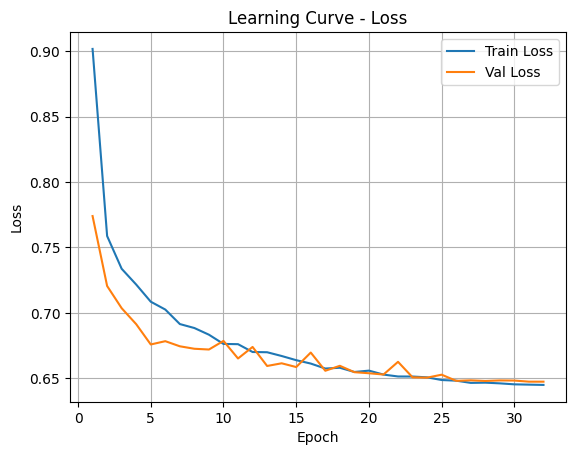

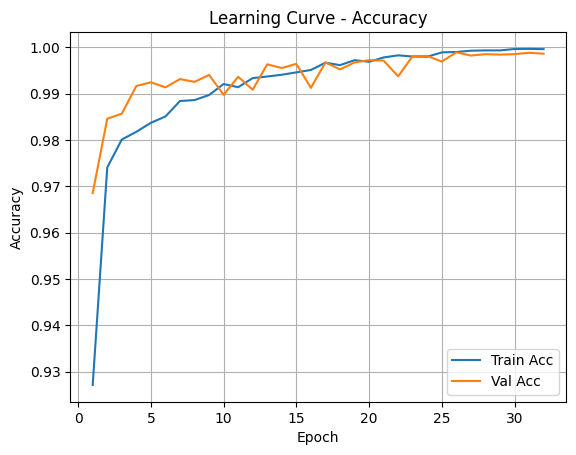

 Saved: out/learning_curve_loss.png out/learning_curve_acc.png


In [17]:

# SECTION 5) Learning Curves + Save


epochs_r = history["epoch"]

# Loss curve
plt.figure()
plt.plot(epochs_r, history["train_loss"], label="Train Loss")
plt.plot(epochs_r, history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid(True)
plt.savefig(OUT_DIR/"learning_curve_loss.png", dpi=200, bbox_inches="tight")
plt.show()

# Acc curve
plt.figure()
plt.plot(epochs_r, history["train_acc"], label="Train Acc")
plt.plot(epochs_r, history["val_acc"],   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(OUT_DIR/"learning_curve_acc.png", dpi=200, bbox_inches="tight")
plt.show()

print(" Saved:",
      OUT_DIR/"learning_curve_loss.png",
      OUT_DIR/"learning_curve_acc.png")


===== Final Classification Report — TEST =====

                                     precision    recall  f1-score   support

                 Apple - Apple Scab     1.0000    1.0000    1.0000       378
                  Apple - Black Rot     1.0000    0.9973    0.9987       372
           Apple - Cedar Apple Rust     1.0000    1.0000    1.0000       326
                    Apple - Healthy     0.9973    1.0000    0.9987       375
       Bell Pepper - Bacterial Spot     1.0000    1.0000    1.0000       358
              Bell Pepper - Healthy     1.0000    1.0000    1.0000       372
                   Cherry - Healthy     1.0000    0.9971    0.9985       343
            Cherry - Powdery Mildew     1.0000    1.0000    1.0000       315
Corn (Maize) - Cercospora Leaf Spot     0.9934    0.9805    0.9869       308
         Corn (Maize) - Common Rust     1.0000    0.9972    0.9986       357
             Corn (Maize) - Healthy     1.0000    1.0000    1.0000       349
Corn (Maize) - Northern Le

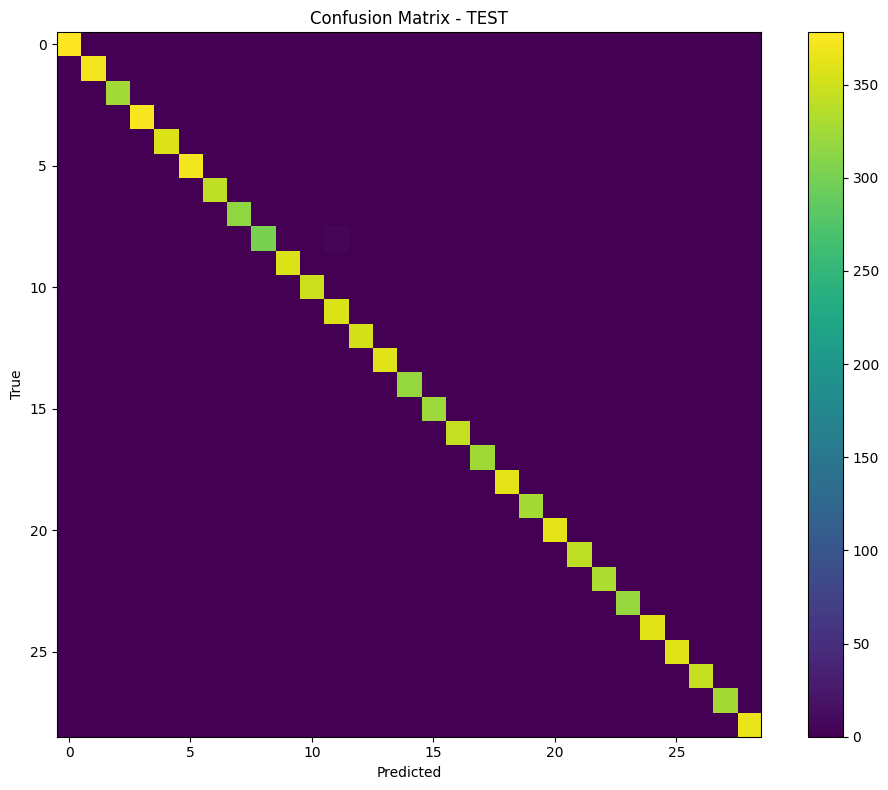

 Saved: out/confusion_matrix.png


In [18]:

# SECTION 6) Final TEST + Confusion Matrix + Save


model.load_state_dict(best_wts)

test_loss, test_acc, y_true, y_pred, y_prob = run_epoch(test_loader, training=False)

print("\n===== Final Classification Report — TEST =====\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))
print("Test loss:", round(test_loss,4), "| Test acc:", round(test_acc,4))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - TEST")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUT_DIR/"confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

print(" Saved:", OUT_DIR/"confusion_matrix.png")

NameError: name 'accuracy_score' is not defined

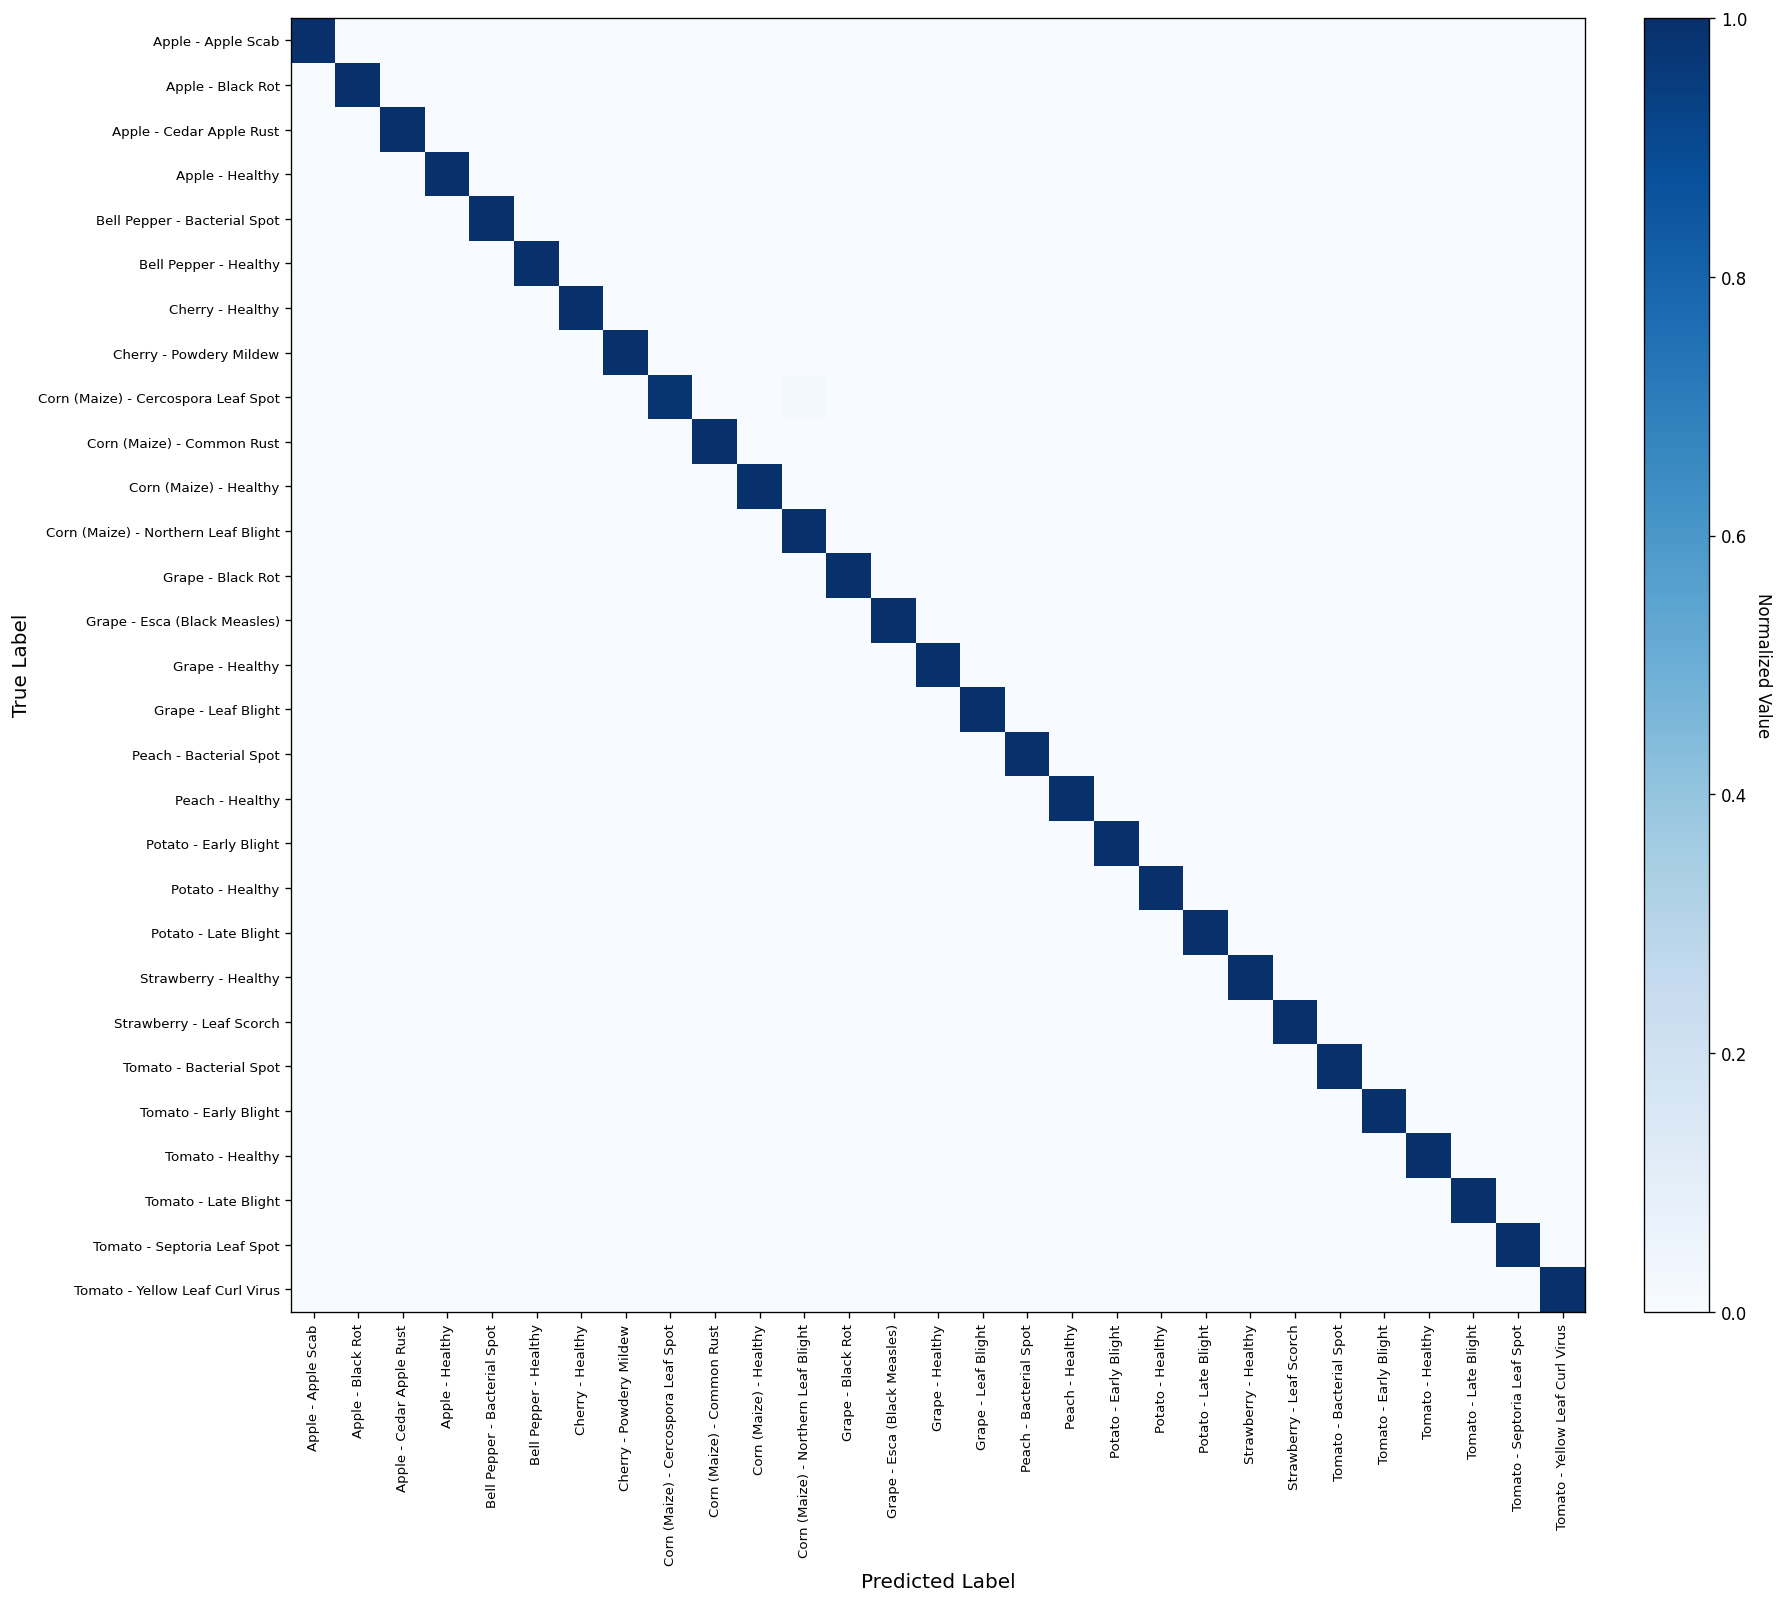

In [20]:

# 8- Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix (non-normalized)
cm = confusion_matrix(y_true, y_pred)

# Row-normalized version
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(16, 14), dpi=120)

# Show matrix
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Normalized Value", rotation=-90, va="bottom")

# Axis settings
ticks = np.arange(len(classes))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(classes, rotation=90, fontsize=8)
ax.set_yticklabels(classes, fontsize=8)

ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_title(
    f"Confusion Matrix (row-normalized) — Test | acc={accuracy_score(y_true, y_pred)*100:.2f}%",
    fontsize=16
)

# Write percentage inside each cell
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        pct = cm_norm[i, j] * 100
        txt = f"{pct:.0f}%"
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()

# Save figure
out_path = OUT_DIR / "confusion_matrix_basic.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


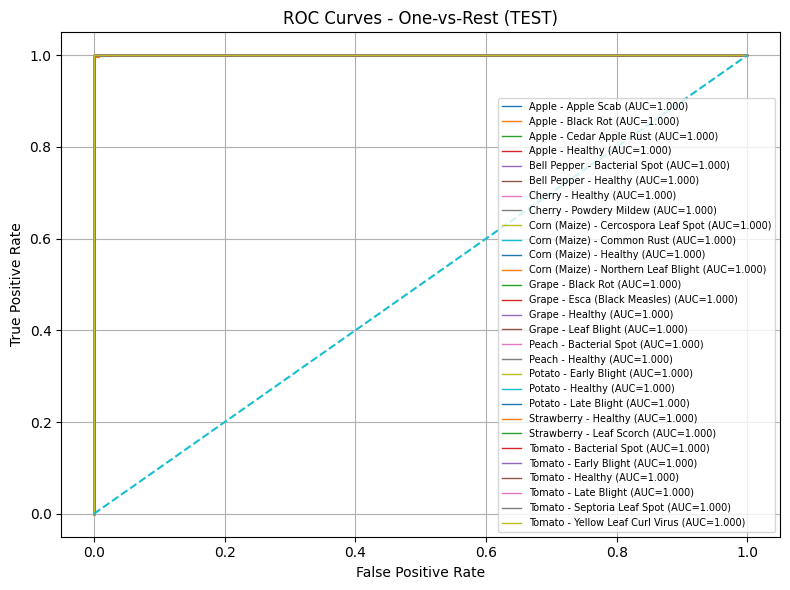

 Saved: out/roc_curves.png out/roc_auc.json


In [21]:

# SECTION 7) ROC Curve (One-vs-Rest Multiclass) + Save


# binarize labels
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot macro-average ROC
plt.figure(figsize=(8,6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], lw=1, label=f"{classes[i]} (AUC={roc_auc[i]:.3f})")

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - One-vs-Rest (TEST)")
plt.legend(fontsize=7, loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR/"roc_curves.png", dpi=220, bbox_inches="tight")
plt.show()

# Save AUC values
with open(OUT_DIR/"roc_auc.json", "w", encoding="utf-8") as f:
    json.dump({classes[i]: float(roc_auc[i]) for i in range(NUM_CLASSES)}, f, indent=2)

print(" Saved:",
      OUT_DIR/"roc_curves.png",
      OUT_DIR/"roc_auc.json")


In [22]:

# TEST METRICS — Accuracy, Precision, Recall, F1

from sklearn.metrics import classification_report, accuracy_score

BEST_PATH = OUT_DIR / "googlenet_best.pt"

# 1) Load best model
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

# 2) Get predictions on test set
test_loss, test_acc, y_true, y_pred, y_prob = run_epoch(test_loader, training=False)

# 3) Print accuracy directly
print(f" Test Accuracy = {test_acc*100:.2f}%")
print("-"*60)

# 4) Classification report (precision, recall, f1)
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("\n Classification Report (Precision / Recall / F1):\n")
print(report)


 Test Accuracy = 99.88%
------------------------------------------------------------

 Classification Report (Precision / Recall / F1):

                                     precision    recall  f1-score   support

                 Apple - Apple Scab     1.0000    1.0000    1.0000       378
                  Apple - Black Rot     1.0000    0.9973    0.9987       372
           Apple - Cedar Apple Rust     1.0000    1.0000    1.0000       326
                    Apple - Healthy     0.9973    1.0000    0.9987       375
       Bell Pepper - Bacterial Spot     1.0000    1.0000    1.0000       358
              Bell Pepper - Healthy     1.0000    1.0000    1.0000       372
                   Cherry - Healthy     1.0000    0.9971    0.9985       343
            Cherry - Powdery Mildew     1.0000    1.0000    1.0000       315
Corn (Maize) - Cercospora Leaf Spot     0.9934    0.9805    0.9869       308
         Corn (Maize) - Common Rust     1.0000    0.9972    0.9986       357
             Co

In [23]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:

# Sanity-Check 1: Check exact duplicates across splits (MD5)

import hashlib, os
from pathlib import Path
from PIL import Image

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

def md5_file(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def collect_hashes(root_dir):
    root_dir = Path(root_dir)
    hashes = {}
    for p in root_dir.rglob("*"):
        if p.suffix.lower() in IMG_EXTS:
            h = md5_file(p)
            hashes[h] = str(p)
    return set(hashes.keys())

train_hashes = collect_hashes(TRAIN_DIR)
val_hashes   = collect_hashes(VAL_DIR)
test_hashes  = collect_hashes(TEST_DIR)

dup_train_val  = train_hashes.intersection(val_hashes)
dup_train_test = train_hashes.intersection(test_hashes)
dup_val_test   = val_hashes.intersection(test_hashes)

print("Duplicates Train ∩ Val :", len(dup_train_val))
print("Duplicates Train ∩ Test:", len(dup_train_test))
print("Duplicates Val ∩ Test  :", len(dup_val_test))

if len(dup_train_val)==0 and len(dup_train_test)==0 and len(dup_val_test)==0:
    print(" No exact duplicates found across splits.")
else:
    print(" Warning: duplicates exist across splits!")

In [ ]:

# Sanity-Check 2: Compare Val vs Test accuracy

val_loss, val_acc, *_  = run_epoch(val_loader,  training=False)
test_loss, test_acc, *_ = run_epoch(test_loader, training=False)

print(f" Val  Accuracy = {val_acc*100:.2f}% | Val  Loss = {val_loss:.4f}")
print(f" Test Accuracy = {test_acc*100:.2f}% | Test Loss = {test_loss:.4f}")
print(f" Gap (Val - Test) = {(val_acc-test_acc)*100:.2f}%")

In [ ]:

# Sanity-Check 3: Show hardest 10 misclassified images


import matplotlib.pyplot as plt
import numpy as np

model.eval()
wrong = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb)
        logits = out.logits if hasattr(out, "logits") else out
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(1)

        for i in range(xb.size(0)):
            if preds[i] != yb[i]:
                conf = probs[i, preds[i]].item()
                wrong.append((xb[i].cpu(), yb[i].cpu().item(), preds[i].cpu().item(), conf))

# sort by confidence (hardest = model confident but wrong)
wrong = sorted(wrong, key=lambda x: x[3], reverse=True)[:10]

print("Total wrong predictions:", len(wrong))

if len(wrong) == 0:
    print(" No mistakes found in test set!")
else:
    plt.figure(figsize=(14,8))
    for idx, (img_t, true_id, pred_id, conf) in enumerate(wrong):
        plt.subplot(2,5,idx+1)
        img_np = img_t.permute(1,2,0).numpy()
        # unnormalize for display
        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])
        img_np = (img_np*std + mean).clip(0,1)

        plt.imshow(img_np)
        plt.title(f"T:{classes[true_id]}\nP:{classes[pred_id]}\nconf={conf:.2f}", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()